In [10]:
import os
import numpy as np
import pandas as pd
import scipy.integrate as sci
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy import units as u
from astropy import constants as const
from scipy.special import gamma as fgamma

# ───────────────────────────────────────────────────────────────
# 0) Load data
# ───────────────────────────────────────────────────────────────
tab = Table.read(r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/SGLTable03.fits")

# Make plain numpy arrays (drop units if present)
zl        = np.asarray(tab['zl'], dtype=float)
zs        = np.asarray(tab['zs'], dtype=float)
theta_ap_arcsec = np.asarray(tab['theta_ap'], dtype=float)
thetaE_arcsec = np.asarray(tab['theta_E'], dtype=float)
sigma_ap  = np.asarray(tab['sigma_ap'], dtype=float)

# Aperture‐correction parameters (defined but not used below)
eta, eta_err = -0.066, 0.035
def calibrate(sigma_ap_nocal, theta_eff, theta_ap, eta):
    return sigma_ap_nocal * (theta_eff / (2*theta_ap))**eta
def sigma_uncertainty(sigma_ap_nocal, sigma_ap_err_nocal, theta_eff, theta_ap, eta, eta_err):
    fac = (theta_eff / (2*theta_ap))
    err_stat2 = sigma_ap_err_nocal**2
    err_AC2   = (sigma_ap_err_nocal**2) * fac**(2*eta) \
              + (sigma_ap_nocal**2) * fac**(2*eta) * (np.log(fac)**2) * (eta_err**2)
    err_sys2  = (0.03 * sigma_ap_nocal)**2
    return np.sqrt(err_stat2 + err_AC2 + err_sys2)

# ───────────────────────────────────────────────────────────────
# Cosmology & distances (constant-w)
# ───────────────────────────────────────────────────────────────
H0 = 73.6                  # km/s/Mpc
Om = 0.334
Ok = 0.0
w  = -1.0

c_kms = const.c.to(u.km/u.s).value   # km/s
D_H   = c_kms / H0                   # Mpc

def _sinn(ok, x):
    """Curvature helper: sin, sinh, or identity."""
    if ok < 0:   # closed
        a = np.sqrt(abs(ok))
        return np.sin(a*x)/a
    elif ok > 0: # open
        a = np.sqrt(abs(ok))
        return np.sinh(a*x)/a
    else:
        return x

def integrate_da_constw(z1, z2, w, Ok, H0=H0, Om=Om):
    """
    Angular diameter distance D_A(z1,z2) in Mpc for constant w, curvature Ok.
    Accepts scalars or arrays; broadcasts z1/z2 to same shape.
    """
    z1 = np.atleast_1d(z1).astype(float)
    z2 = np.atleast_1d(z2).astype(float)
    if z1.size > 1 and z2.size > 1 and z1.size != z2.size:
        raise ValueError("z1 and z2 must be same length or one of them length 1.")
    if z1.size == 1 and z2.size > 1:
        z1 = np.full_like(z2, z1.item())
    if z2.size == 1 and z1.size > 1:
        z2 = np.full_like(z1, z2.item())

    Ode = 1.0 - Om - Ok

    def Ez_inv(z):
        Ez2 = Om*(1+z)**3 + Ok*(1+z)**2 + Ode*(1+z)**(3*(1+w))
        return 1.0/np.sqrt(Ez2)

    out = np.empty_like(z1, dtype=float)
    for i, (za, zb) in enumerate(np.column_stack([z1, z2])):
        val, _ = sci.quad(Ez_inv, za, zb)
        out[i] = (D_H / (1.0 + zb)) * _sinn(Ok, val)
    return out

# Distances
D_ls = integrate_da_constw(zl, zs, w, Ok, H0=H0, Om=Om)
D_l  = integrate_da_constw(0.0, zl, w, Ok, H0=H0, Om=Om)
D_s  = integrate_da_constw(0.0, zs, w, Ok, H0=H0, Om=Om)

# ───────────────────────────────────────────────────────────────
# σ–θ_E relation for a spherical power-law (γ)
# ───────────────────────────────────────────────────────────────
pi = np.pi

def f_gamma(g):
    a = -1.0/np.sqrt(pi)
    b = ((5.0 - 2.0*g)*(1.0 - g)) / (3.0 - g)
    c = fgamma(g - 1.0) / fgamma(g - 1.5)
    d = fgamma((g - 1.0)/2.0) / fgamma(g/2.0)
    return a * b * c * d**2

def f_prime(g, d, beta):
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (g + d - 5.0) * (g + d - 2.0 - 2.0*beta) / (d - 3.0)
    num = fgamma((g + d - 2.0)/2.0) * fgamma((g + d)/2.0)
    den = fgamma((g + d)/2.0) * fgamma((g + d - 3.0)/2.0) \
        - beta * fgamma((g + d - 2.0)/2.0) * fgamma((g + d - 1.0)/2.0)
    term3 = fgamma((d - 1.0)/2.0) * fgamma((g - 1.0)/2.0) / (fgamma(d/2.0) * fgamma(g/2.0))
    return pref * term1 * (num/den) * term3

def thetaE_theo(gamma, Dls, Ds, theta_ap_rad, sigma_ap_kms):
    """
    Returns θ_E in radians for (possibly array) gamma.
    Uses the standard power-law relation; reduces to SIS when gamma=2.
    """
    p1 = 4.0*pi*(sigma_ap_kms**2)/(c_kms**2) * (Dls/Ds) * (theta_ap_rad**(gamma - 2.0)) * f_gamma(gamma)
    return p1**(1.0/(gamma - 1.0))

def thetaE_theo_EPL(g,d,b, Dls, Ds, theta_ap_rad, sigma_ap_kms):
    """
    Returns θ_E in radians for (possibly array) gamma.
    Uses the standard power-law relation; reduces to SIS when gamma=2.
    """
    p1 = 4.0*pi*(sigma_ap_kms**2)/(c_kms**2) * (Dls/Ds) * (theta_ap_rad**(g - 2.0)) * f_prime(g,d,b)
    return p1**(1.0/(g - 1.0))


879.3934378892076 1607.1680734566967 292.0985694543623


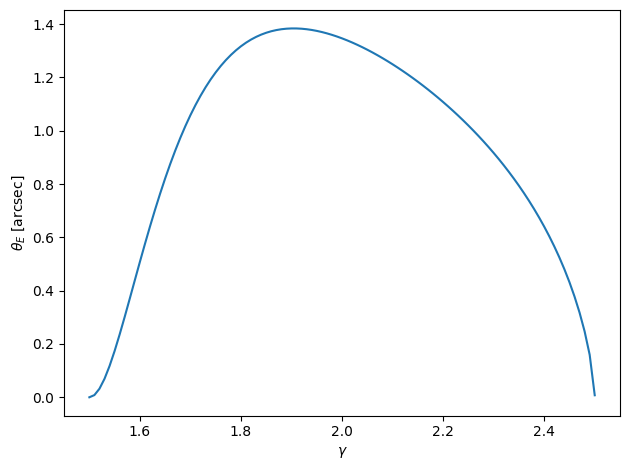

In [3]:
# Prepare inputs (angles in radians)
theta_ap_rad = (theta_ap_arcsec * u.arcsec).to(u.rad).value

# Choose one lens to illustrate
idx = 1
print(D_ls[idx], D_s[idx], sigma_ap[idx])
gamma_list = np.linspace(1.5001, 2.4999, 101)  # avoid the pole at 1.5

thetaE_rad = thetaE_theo(gamma_list, D_ls[idx], D_s[idx], theta_ap_rad[idx], sigma_ap[idx])
thetaE_arcsec = (thetaE_rad * u.rad).to(u.arcsec).value

# Quick check: f_gamma(2) → 1 (SIS limit), so θ_E should match SIS at γ=2
# Plot
plt.plot(gamma_list, thetaE_arcsec)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\theta_E$ [arcsec]')
plt.tight_layout()
plt.show()

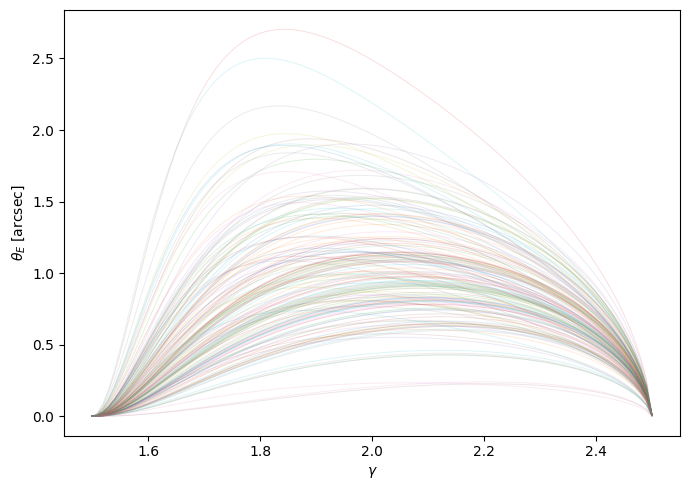

In [10]:
# Sweep gamma and plot θ_E(γ) for every lens on one figure
gamma_list = np.linspace(1.5001, 2.4999, 101)  # avoid pole at 1.5

plt.figure(figsize=(7,5))
for i in range(len(zl)):
    thetaE_rad_i = thetaE_theo(gamma_list, D_ls[i], D_s[i], theta_ap_rad[i], sigma_ap[i])
    thetaE_arcsec_i = (thetaE_rad_i * u.rad).to(u.arcsec).value
    plt.plot(gamma_list, thetaE_arcsec_i, lw=0.7, alpha=0.15)

plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\theta_E\ \mathrm{[arcsec]}$')
plt.tight_layout()
plt.show()


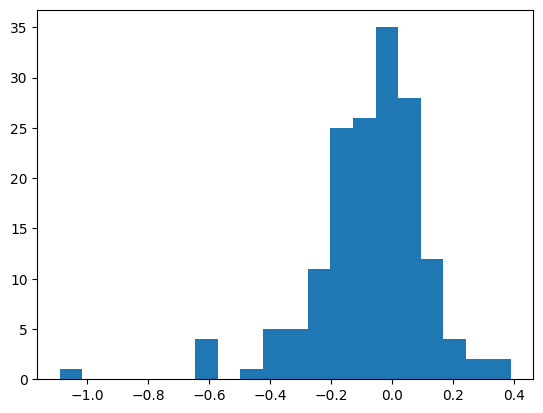

In [19]:
# Prepare inputs (angles in radians)
theta_ap_rad = (theta_ap_arcsec * u.arcsec).to(u.rad).value

# Choose one lens to illustrate
idx = 1
gamma_list = np.linspace(1.5001, 2.4999, 101)  # avoid the pole at 1.5


thetaE_star = 206265*thetaE_theo(2.0, D_ls, D_s, theta_ap_rad, 161.)

sigma_infer = 161.0*np.sqrt(tab['theta_E']/thetaE_star)

res_sigma = (tab['sigma_ap']-sigma_infer)/tab['sigma_ap']

plt.hist(res_sigma, bins=20)
plt.show()

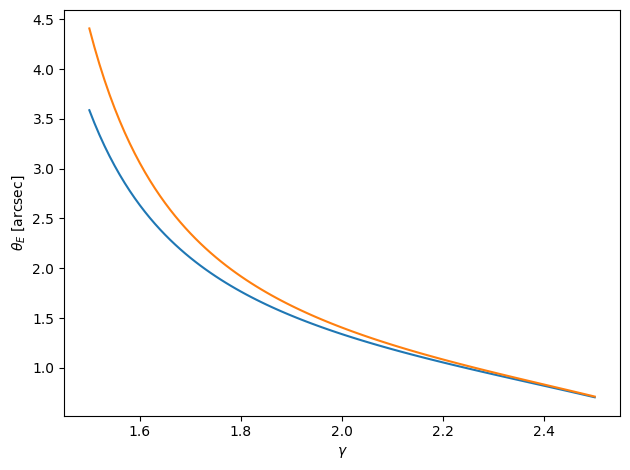

In [21]:
# Prepare inputs (angles in radians)
theta_ap_rad = (theta_ap_arcsec * u.arcsec).to(u.rad).value

# Choose one lens to illustrate
idx = 1
gamma_list = np.linspace(1.5001, 2.4999, 101)  # avoid the pole at 1.5

thetaE_rad01 = thetaE_theo_EPL(gamma_list,2.173,0.2, D_ls[idx], D_s[idx], theta_ap_rad[idx], sigma_ap[idx])
thetaE_arcsec01 = (thetaE_rad01 * u.rad).to(u.arcsec).value

thetaE_rad02 = thetaE_theo_EPL(gamma_list,2.173,0.1, D_ls[idx], D_s[idx], theta_ap_rad[idx], sigma_ap[idx])
thetaE_arcsec02 = (thetaE_rad02 * u.rad).to(u.arcsec).value

# Quick check: f_gamma(2) → 1 (SIS limit), so θ_E should match SIS at γ=2
# Plot
plt.plot(gamma_list, thetaE_arcsec01)
plt.plot(gamma_list, thetaE_arcsec02)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\theta_E$ [arcsec]')
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from astropy import units as u

# 1) 选择 gamma 网格（避开 1.5 的极点）
gamma_list = np.linspace(1.5001, 2.4999, 800)

# 2) 读取观测的 θE（单位：arcsec），自动尝试常见列名
def get_thetaE_obs(table):
    candidates = [
        "thetaE", "theta_E", "theta_Ein", "theta_E_arcsec",
        "theta_e_arcsec", "Einstein_Radius", "thetaEin"
    ]
    for name in candidates:
        if name in table.colnames:
            return np.asarray(table[name], dtype=float), name
    raise KeyError(f"未找到观测 θE 列名，请检查表头：{table.colnames}")

thetaE_obs_arcsec, used_col = get_thetaE_obs(tab)  # 如果你变量名是 df，就改成 df

# 3) 逐个系统计算理论 θE(γ) 的最大值及对应 γ
N = len(D_ls)
thetaE_theo_max = np.empty(N, dtype=float)
gamma_at_max    = np.empty(N, dtype=float)

for i in range(N):
    curve_rad = thetaE_theo(gamma_list, D_ls[i], D_s[i], theta_ap_rad[i], sigma_ap[i])
    curve_arcsec = (curve_rad * u.rad).to(u.arcsec).value
    j = np.nanargmax(curve_arcsec)           # 忽略可能的 NaN
    thetaE_theo_max[i] = curve_arcsec[j]
    gamma_at_max[i]    = gamma_list[j]

# 4) 比较观测与理论最大值，取出观测更大的索引
tol = 1e-6  # 数值容差（arcsec）
bad_idx = np.where(thetaE_obs_arcsec > thetaE_theo_max + tol)[0]

print(f"column name: {used_col}")
print(f"{bad_idx.size}/{N} 个系统满足 θE_obs > θE_max(theory)")
print("对应索引:", bad_idx.tolist())

# 可选：看看超过比例
exceed_ratio = thetaE_obs_arcsec[bad_idx] / thetaE_theo_max[bad_idx]

# 可选：保存索引到文件
# np.savetxt("indices_thetaE_obs_gt_theorymax.txt", bad_idx, fmt="%d")


column name: theta_E
102/161 个系统满足 θE_obs > θE_max(theory)
对应索引: [1, 2, 3, 4, 5, 7, 8, 10, 12, 16, 17, 18, 19, 20, 22, 23, 24, 27, 29, 30, 32, 33, 35, 39, 40, 43, 45, 47, 49, 51, 52, 55, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 71, 72, 73, 74, 75, 76, 77, 79, 80, 82, 83, 84, 86, 87, 88, 89, 92, 93, 94, 95, 96, 97, 98, 100, 102, 103, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 116, 117, 118, 119, 121, 122, 124, 126, 127, 131, 137, 138, 139, 140, 141, 144, 146, 148, 150, 151, 152, 153, 154, 156]


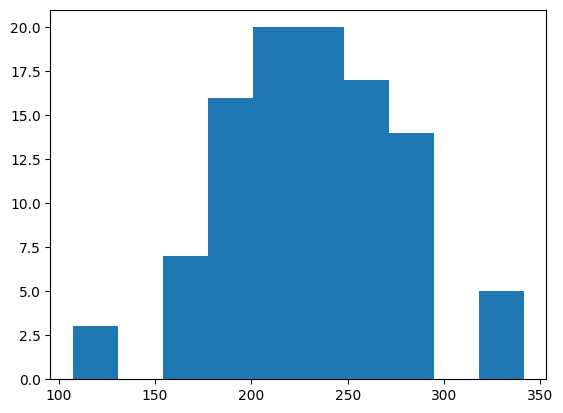

In [5]:
sigma_bad = tab['sigma_ap'][bad_idx]

plt.hist(sigma_bad, bins=10)
plt.show()

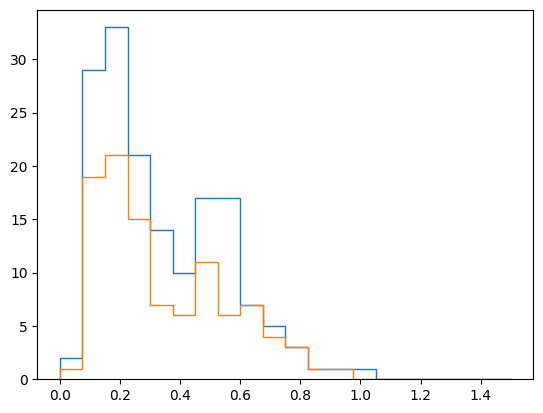

In [7]:
zl = tab['zl']
zl_bad = tab['zl'][bad_idx]

bin_edges = np.linspace(0.0, 1.5, 21)  

plt.hist(zl, bins=bin_edges, histtype='step',label='zl')
plt.hist(zl_bad, bins=bin_edges, histtype='step',label='zl_bad')
plt.show()

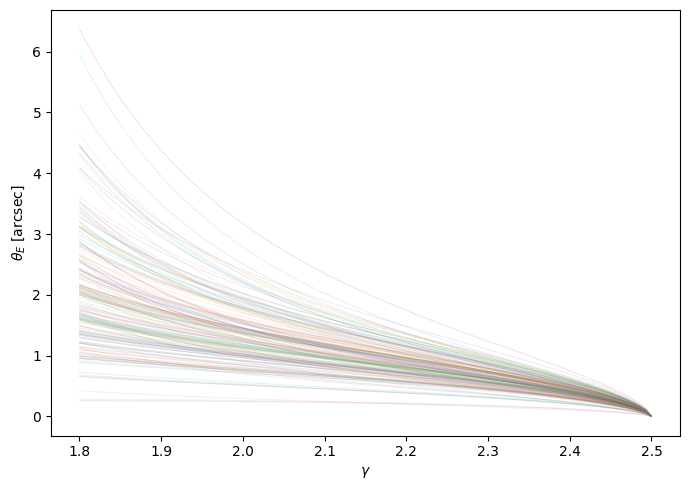

In [39]:
# Sweep gamma and plot θ_E(γ) for every lens on one figure
gamma_list = np.linspace(1.8001, 2.4999, 101)  # avoid pole at 1.5

plt.figure(figsize=(7,5))
for i in range(len(zl)):
    thetaE_rad_i = thetaE_theo_EPL(gamma_list,2.5,-0.1, D_ls[i], D_s[i], theta_ap_rad[i], sigma_ap[i])
    thetaE_arcsec_i = (thetaE_rad_i * u.rad).to(u.arcsec).value
    plt.plot(gamma_list, thetaE_arcsec_i, lw=0.7, alpha=0.15)

plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\theta_E\ \mathrm{[arcsec]}$')
plt.tight_layout()
plt.show()


In [35]:
import numpy as np
from astropy import units as u

# 1) 选择 gamma 网格（避开 1.5 的极点）
gamma_list = np.linspace(1.5001, 2.4999, 800)

# 2) 读取观测的 θE（单位：arcsec），自动尝试常见列名
def get_thetaE_obs(table):
    candidates = [
        "thetaE", "theta_E", "theta_Ein", "theta_E_arcsec",
        "theta_e_arcsec", "Einstein_Radius", "thetaEin"
    ]
    for name in candidates:
        if name in table.colnames:
            return np.asarray(table[name], dtype=float), name
    raise KeyError(f"未找到观测 θE 列名，请检查表头：{table.colnames}")

thetaE_obs_arcsec, used_col = get_thetaE_obs(tab)  # 如果你变量名是 df，就改成 df

# 3) 逐个系统计算理论 θE(γ) 的最大值及对应 γ
N = len(D_ls)
thetaE_theo_max = np.empty(N, dtype=float)
gamma_at_max    = np.empty(N, dtype=float)

for i in range(N):
    curve_rad = thetaE_theo_EPL(gamma_list,2.5,-0.1, D_ls[i], D_s[i], theta_ap_rad[i], sigma_ap[i])
    curve_arcsec = (curve_rad * u.rad).to(u.arcsec).value
    j = np.nanargmax(curve_arcsec)           # 忽略可能的 NaN
    thetaE_theo_max[i] = curve_arcsec[j]
    gamma_at_max[i]    = gamma_list[j]

# 4) 比较观测与理论最大值，取出观测更大的索引
tol = 1e-6  # 数值容差（arcsec）
bad_idx = np.where(thetaE_obs_arcsec > thetaE_theo_max + tol)[0]

print(f"column name: {used_col}")
print(f"{bad_idx.size}/{N} 个系统满足 θE_obs > θE_max(theory)")
print("对应索引:", bad_idx.tolist())

# 可选：看看超过比例
exceed_ratio = thetaE_obs_arcsec[bad_idx] / thetaE_theo_max[bad_idx]

# 可选：保存索引到文件
# np.savetxt("indices_thetaE_obs_gt_theorymax.txt", bad_idx, fmt="%d")


column name: theta_E
3/161 个系统满足 θE_obs > θE_max(theory)
对应索引: [105, 106, 107]


In [37]:
tab['sigma_ap'][bad_idx]
# tab['theta_E'][bad_idx]

107.38955311187371
127.30026761691884
174.70591462811595


# simulation data

In [44]:
import os
import numpy as np
import pandas as pd
import scipy.integrate as sci
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy import units as u
from astropy import constants as const
from scipy.special import gamma as fgamma

# ───────────────────────────────────────────────────────────────
# 0) Load data
# ───────────────────────────────────────────────────────────────
tab = Table.read(r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/LSSTa_sim_l3_w_evoPL.fits")

# Make plain numpy arrays (drop units if present)
zl        = np.asarray(tab['zl'], dtype=float)
zs        = np.asarray(tab['zs'], dtype=float)
theta_ap_arcsec = np.asarray(tab['theta_ap'], dtype=float)
thetaE_arcsec = np.asarray(tab['theta_E'], dtype=float)
sigma_ap  = np.asarray(tab['sigma_ap'], dtype=float)

# Aperture‐correction parameters (defined but not used below)
eta, eta_err = -0.066, 0.035
def calibrate(sigma_ap_nocal, theta_eff, theta_ap, eta):
    return sigma_ap_nocal * (theta_eff / (2*theta_ap))**eta
def sigma_uncertainty(sigma_ap_nocal, sigma_ap_err_nocal, theta_eff, theta_ap, eta, eta_err):
    fac = (theta_eff / (2*theta_ap))
    err_stat2 = sigma_ap_err_nocal**2
    err_AC2   = (sigma_ap_err_nocal**2) * fac**(2*eta) \
              + (sigma_ap_nocal**2) * fac**(2*eta) * (np.log(fac)**2) * (eta_err**2)
    err_sys2  = (0.03 * sigma_ap_nocal)**2
    return np.sqrt(err_stat2 + err_AC2 + err_sys2)

# ───────────────────────────────────────────────────────────────
# Cosmology & distances (constant-w)
# ───────────────────────────────────────────────────────────────
H0 = 70.0                 # km/s/Mpc
Om = 0.3
Ok = 0.0
w  = -1.0

c_kms = const.c.to(u.km/u.s).value   # km/s
D_H   = c_kms / H0                   # Mpc

def _sinn(ok, x):
    """Curvature helper: sin, sinh, or identity."""
    if ok < 0:   # closed
        a = np.sqrt(abs(ok))
        return np.sin(a*x)/a
    elif ok > 0: # open
        a = np.sqrt(abs(ok))
        return np.sinh(a*x)/a
    else:
        return x

def integrate_da_constw(z1, z2, w, Ok, H0=H0, Om=Om):
    """
    Angular diameter distance D_A(z1,z2) in Mpc for constant w, curvature Ok.
    Accepts scalars or arrays; broadcasts z1/z2 to same shape.
    """
    z1 = np.atleast_1d(z1).astype(float)
    z2 = np.atleast_1d(z2).astype(float)
    if z1.size > 1 and z2.size > 1 and z1.size != z2.size:
        raise ValueError("z1 and z2 must be same length or one of them length 1.")
    if z1.size == 1 and z2.size > 1:
        z1 = np.full_like(z2, z1.item())
    if z2.size == 1 and z1.size > 1:
        z2 = np.full_like(z1, z2.item())

    Ode = 1.0 - Om - Ok

    def Ez_inv(z):
        Ez2 = Om*(1+z)**3 + Ok*(1+z)**2 + Ode*(1+z)**(3*(1+w))
        return 1.0/np.sqrt(Ez2)

    out = np.empty_like(z1, dtype=float)
    for i, (za, zb) in enumerate(np.column_stack([z1, z2])):
        val, _ = sci.quad(Ez_inv, za, zb)
        out[i] = (D_H / (1.0 + zb)) * _sinn(Ok, val)
    return out

# Distances
D_ls = integrate_da_constw(zl, zs, w, Ok, H0=H0, Om=Om)
D_l  = integrate_da_constw(0.0, zl, w, Ok, H0=H0, Om=Om)
D_s  = integrate_da_constw(0.0, zs, w, Ok, H0=H0, Om=Om)

# ───────────────────────────────────────────────────────────────
# σ–θ_E relation for a spherical power-law (γ)
# ───────────────────────────────────────────────────────────────
pi = np.pi

def f_gamma(g):
    a = -1.0/np.sqrt(pi)
    b = ((5.0 - 2.0*g)*(1.0 - g)) / (3.0 - g)
    c = fgamma(g - 1.0) / fgamma(g - 1.5)
    d = fgamma((g - 1.0)/2.0) / fgamma(g/2.0)
    return a * b * c * d**2

def f_prime(g, d, beta):
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (g + d - 5.0) * (g + d - 2.0 - 2.0*beta) / (d - 3.0)
    num = fgamma((g + d - 2.0)/2.0) * fgamma((g + d)/2.0)
    den = fgamma((g + d)/2.0) * fgamma((g + d - 3.0)/2.0) \
        - beta * fgamma((g + d - 2.0)/2.0) * fgamma((g + d - 1.0)/2.0)
    term3 = fgamma((d - 1.0)/2.0) * fgamma((g - 1.0)/2.0) / (fgamma(d/2.0) * fgamma(g/2.0))
    return pref * term1 * (num/den) * term3

def thetaE_theo(gamma, Dls, Ds, theta_ap_rad, sigma_ap_kms):
    """
    Returns θ_E in radians for (possibly array) gamma.
    Uses the standard power-law relation; reduces to SIS when gamma=2.
    """
    p1 = 4.0*pi*(sigma_ap_kms**2)/(c_kms**2) * (Dls/Ds) * (theta_ap_rad**(gamma - 2.0)) * f_gamma(gamma)
    return p1**(1.0/(gamma - 1.0))

def thetaE_theo_EPL(g,d,b, Dls, Ds, theta_ap_rad, sigma_ap_kms):
    """
    Returns θ_E in radians for (possibly array) gamma.
    Uses the standard power-law relation; reduces to SIS when gamma=2.
    """
    p1 = 4.0*pi*(sigma_ap_kms**2)/(c_kms**2) * (Dls/Ds) * (theta_ap_rad**(g - 2.0)) * f_prime(g,d,b)
    return p1**(1.0/(g - 1.0))


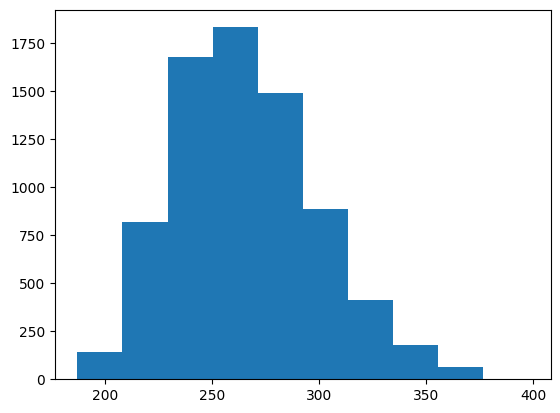

In [45]:
plt.hist(sigma_ap, bins=10)
plt.show()

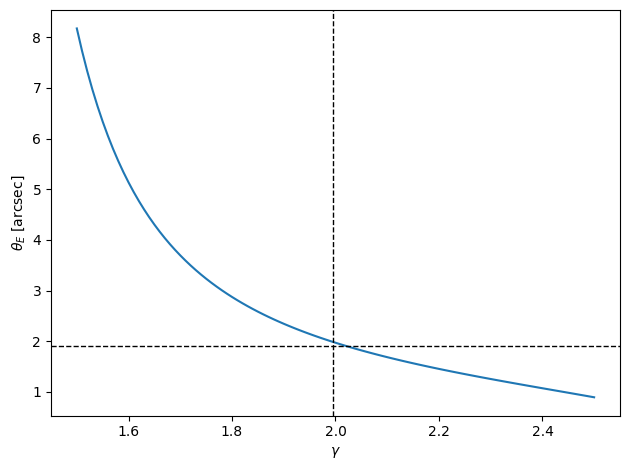

In [48]:
# Prepare inputs (angles in radians)
theta_ap_rad = (theta_ap_arcsec * u.arcsec).to(u.rad).value

# Choose one lens to illustrate
idx = 300
gamma_list = np.linspace(1.5001, 2.4999, 101)  # avoid the pole at 1.5

thetaE_rad01 = thetaE_theo_EPL(gamma_list,2.26-0.16*zl[idx],0.0, D_ls[idx], D_s[idx], theta_ap_rad[idx], sigma_ap[idx])
thetaE_arcsec01 = (thetaE_rad01 * u.rad).to(u.arcsec).value

# Quick check: f_gamma(2) → 1 (SIS limit), so θ_E should match SIS at γ=2
# Plot
plt.plot(gamma_list, thetaE_arcsec01)
# plt.plot(gamma_list, thetaE_arcsec02)
plt.axhline(y=thetaE_arcsec[idx], c='k', ls='--', lw=1.0)
plt.axvline(x=2.054-0.19*zl[idx], c='k', ls='--', lw=1.0)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\theta_E$ [arcsec]')
plt.tight_layout()
plt.show()

# f function

In [ ]:
def f_prime(g, d, beta):
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (g + d - 5.0) * (g + d - 2.0 - 2.0*beta) / (d - 3.0)
    num = fgamma((g + d - 2.0)/2.0) * fgamma((g + d)/2.0)
    den = fgamma((g + d)/2.0) * fgamma((g + d - 3.0)/2.0) \
        - beta * fgamma((g + d - 2.0)/2.0) * fgamma((g + d - 1.0)/2.0)
    term3 = fgamma((d - 1.0)/2.0) * fgamma((g - 1.0)/2.0) / (fgamma(d/2.0) * fgamma(g/2.0))
    return pref * term1 * (num/den) * term3

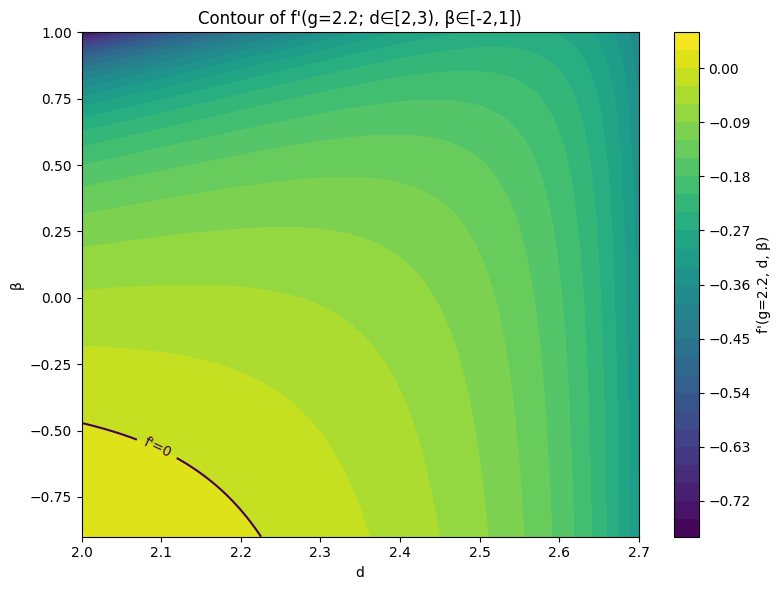

In [77]:
# Contour plot for f_prime(g, d, beta) with g fixed to 2.078
# d in [2, 3) and beta in [-2, 1]
# The function includes potential singularities near d=3 and where the denominator goes to zero;
# we mask those regions so the plot remains readable.

import numpy as np
import matplotlib.pyplot as plt

# Try to import gamma from scipy; fall back to mpmath if unavailable
try:
    from scipy.special import gamma as fgamma
except Exception:
    import mpmath as mp
    fgamma = lambda x: float(mp.gamma(x))

g_fixed = 2.2

def f_prime(g, d, beta):
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (g + d - 5.0) * (g + d - 2.0 - 2.0*beta) / (d - 3.0)
    num = fgamma((g + d - 2.0)/2.0) * fgamma((g + d)/2.0)
    den = fgamma((g + d)/2.0) * fgamma((g + d - 3.0)/2.0) \
        - beta * fgamma((g + d - 2.0)/2.0) * fgamma((g + d - 1.0)/2.0)
    term3 = fgamma((d - 1.0)/2.0) * fgamma((g - 1.0)/2.0) / (fgamma(d/2.0) * fgamma(g/2.0))
    return pref * term1 * (num/den) * term3

# Grid
Nd, Nbeta = 200, 200
d_vals = np.linspace(2.0, 2.7, Nd)  # avoid d=3 exactly to prevent divide-by-zero
beta_vals = np.linspace(-0.9, 1.0, Nbeta)
D, B = np.meshgrid(d_vals, beta_vals, indexing='xy')

# Compute f'
Z = np.empty_like(D, dtype=float)
Z[:] = np.nan

# Mask thresholds
eps_den = 1e-10
eps_d = 1e-6

for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        d = D[i, j]
        beta = B[i, j]
        # Skip points too close to singular d=3
        if abs(d - 3.0) < eps_d:
            continue
        # Compute denominator to check for near-zero (singularity)
        try:
            den = fgamma((g_fixed + d)/2.0) * fgamma((g_fixed + d - 3.0)/2.0) \
                  - beta * fgamma((g_fixed + d - 2.0)/2.0) * fgamma((g_fixed + d - 1.0)/2.0)
        except Exception:
            continue
        if den == 0 or not np.isfinite(den) or abs(den) < eps_den:
            continue
        try:
            val = f_prime(g_fixed, d, beta)
        except Exception:
            val = np.nan
        if np.isfinite(val):
            Z[i, j] = val

# Plot
plt.figure(figsize=(8, 6))
# Use a filled contour for overall structure
levels = 30  # matplotlib will choose levels automatically
cf = plt.contourf(D, B, np.log10(Z), levels=levels)
plt.colorbar(cf, label=f"f'(g={g_fixed}, d, β)")

# Overlay a zero contour if it exists within the domain
try:
    c0 = plt.contour(D, B, np.log10(Z), levels=[0.0], linewidths=1.5)
    plt.clabel(c0, fmt="f'=0")
except Exception:
    pass

plt.xlabel("d")
plt.ylabel("β")
plt.title(f"Contour of f'(g={g_fixed}; d∈[2,3), β∈[-2,1])")
plt.tight_layout()

# # Save figure for download
# out_path = "/mnt/data/fprime_contour_g2p078.png"
# plt.savefig(out_path, dpi=200, bbox_inches="tight")
# out_path


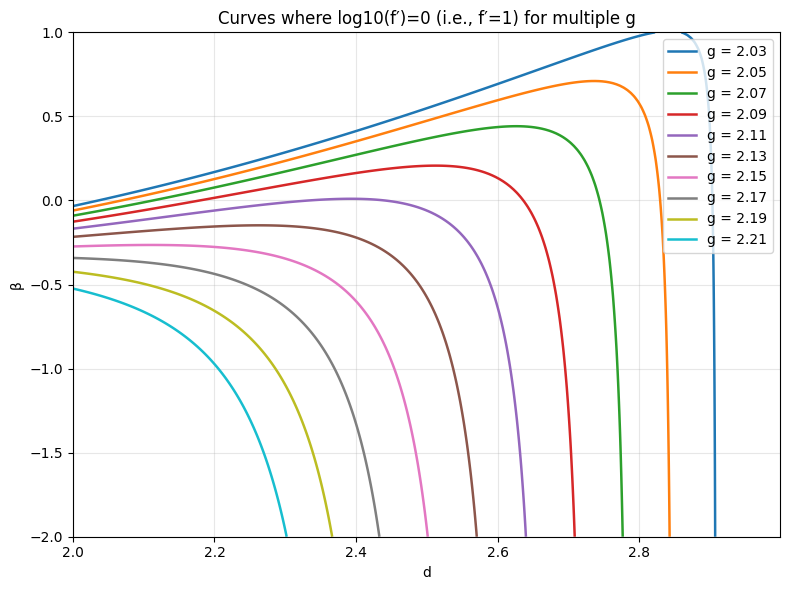

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # 用于图例代理

# Try to import gamma from scipy; fall back to mpmath if unavailable
try:
    from scipy.special import gamma as fgamma
except Exception:
    import mpmath as mp
    fgamma = lambda x: float(mp.gamma(x))

def f_prime(g, d, beta):
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (g + d - 5.0) * (g + d - 2.0 - 2.0*beta) / (d - 3.0)
    num = fgamma((g + d - 2.0)/2.0) * fgamma((g + d)/2.0)
    den = fgamma((g + d)/2.0) * fgamma((g + d - 3.0)/2.0) \
        - beta * fgamma((g + d - 2.0)/2.0) * fgamma((g + d - 1.0)/2.0)
    term3 = fgamma((d - 1.0)/2.0) * fgamma((g - 1.0)/2.0) / (fgamma(d/2.0) * fgamma(g/2.0))
    return pref * term1 * (num/den) * term3

# Grid
Nd, Nbeta = 200, 200
d_vals = np.linspace(2.0, 2.999, Nd)  # exclude exactly 3
beta_vals = np.linspace(-2.0, 1.0, Nbeta)
D, B = np.meshgrid(d_vals, beta_vals, indexing='xy')

g_list = [2.03, 2.05, 2.07, 2.09, 2.11, 2.13,2.15,2.17,2.19,2.21]

plt.figure(figsize=(8, 6))

eps_den = 1e-10
eps_d = 1e-6

# 颜色：tab10 调色板
cmap = plt.get_cmap('tab10')
colors = [cmap(i / max(1, len(g_list) - 1)) for i in range(len(g_list))]

legend_handles, legend_labels = [], []

# 仅画 Z=1 (即 log10 Z = 0) 的等值线
for k, g_fixed in enumerate(g_list):
    Z = np.empty_like(D, dtype=float)
    Z[:] = np.nan
    for i in range(B.shape[0]):
        for j in range(B.shape[1]):
            d = D[i, j]
            beta = B[i, j]
            if abs(d - 3.0) < eps_d:
                continue
            # 先检查分母，避免奇点
            try:
                den = fgamma((g_fixed + d)/2.0) * fgamma((g_fixed + d - 3.0)/2.0) \
                      - beta * fgamma((g_fixed + d - 2.0)/2.0) * fgamma((g_fixed + d - 1.0)/2.0)
            except Exception:
                continue
            if den == 0 or not np.isfinite(den) or abs(den) < eps_den:
                continue
            try:
                val = f_prime(g_fixed, d, beta)
            except Exception:
                val = np.nan
            if np.isfinite(val):
                Z[i, j] = val

    CS = plt.contour(D, B, Z, levels=[1.0], colors=[colors[k]], linewidths=1.8)

    # 若有曲线段，创建与曲线同色的图例代理
    if len(CS.allsegs[0]) > 0:
        handle = Line2D([0], [0], color=colors[k], lw=1.8)
        legend_handles.append(handle)
        legend_labels.append(f"g = {g_fixed:.2f}")

plt.xlabel("d")
plt.ylabel("β")
plt.title("Curves where log10(f′)=0 (i.e., f′=1) for multiple g")
plt.legend(legend_handles, legend_labels, loc="best", frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
